
════════════════════════════════════════════════════════════
  ФУНКЦИЯ : Розенброк
  Метод   : ДФП (Дэвидон-Флэтчер-Пауэл)
════════════════════════════════════════════════════════════
  Стартовая точка       : [-1.5, 2.0]
  Найденный минимум     : [1.0, 1.0]
  Значение f в минимуме : 0.0
  Количество итераций   : 22
  Точек в релакс. посл. : 23
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  ФУНКЦИЯ : Растригин
  Метод   : ДФП (Дэвидон-Флэтчер-Пауэл)
════════════════════════════════════════════════════════════
  Стартовая точка       : [0.45, 0.45]
  Найденный минимум     : [3.9e-5, 2.9e-5]
  Значение f в минимуме : 4.777e-7
  Количество итераций   : 86
  Точек в релакс. посл. : 87
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  ФУНКЦИЯ : Швефель
  Метод   : ДФП (Дэвидон-Флэтчер-Пауэл)
════════════════════════════════════════════════

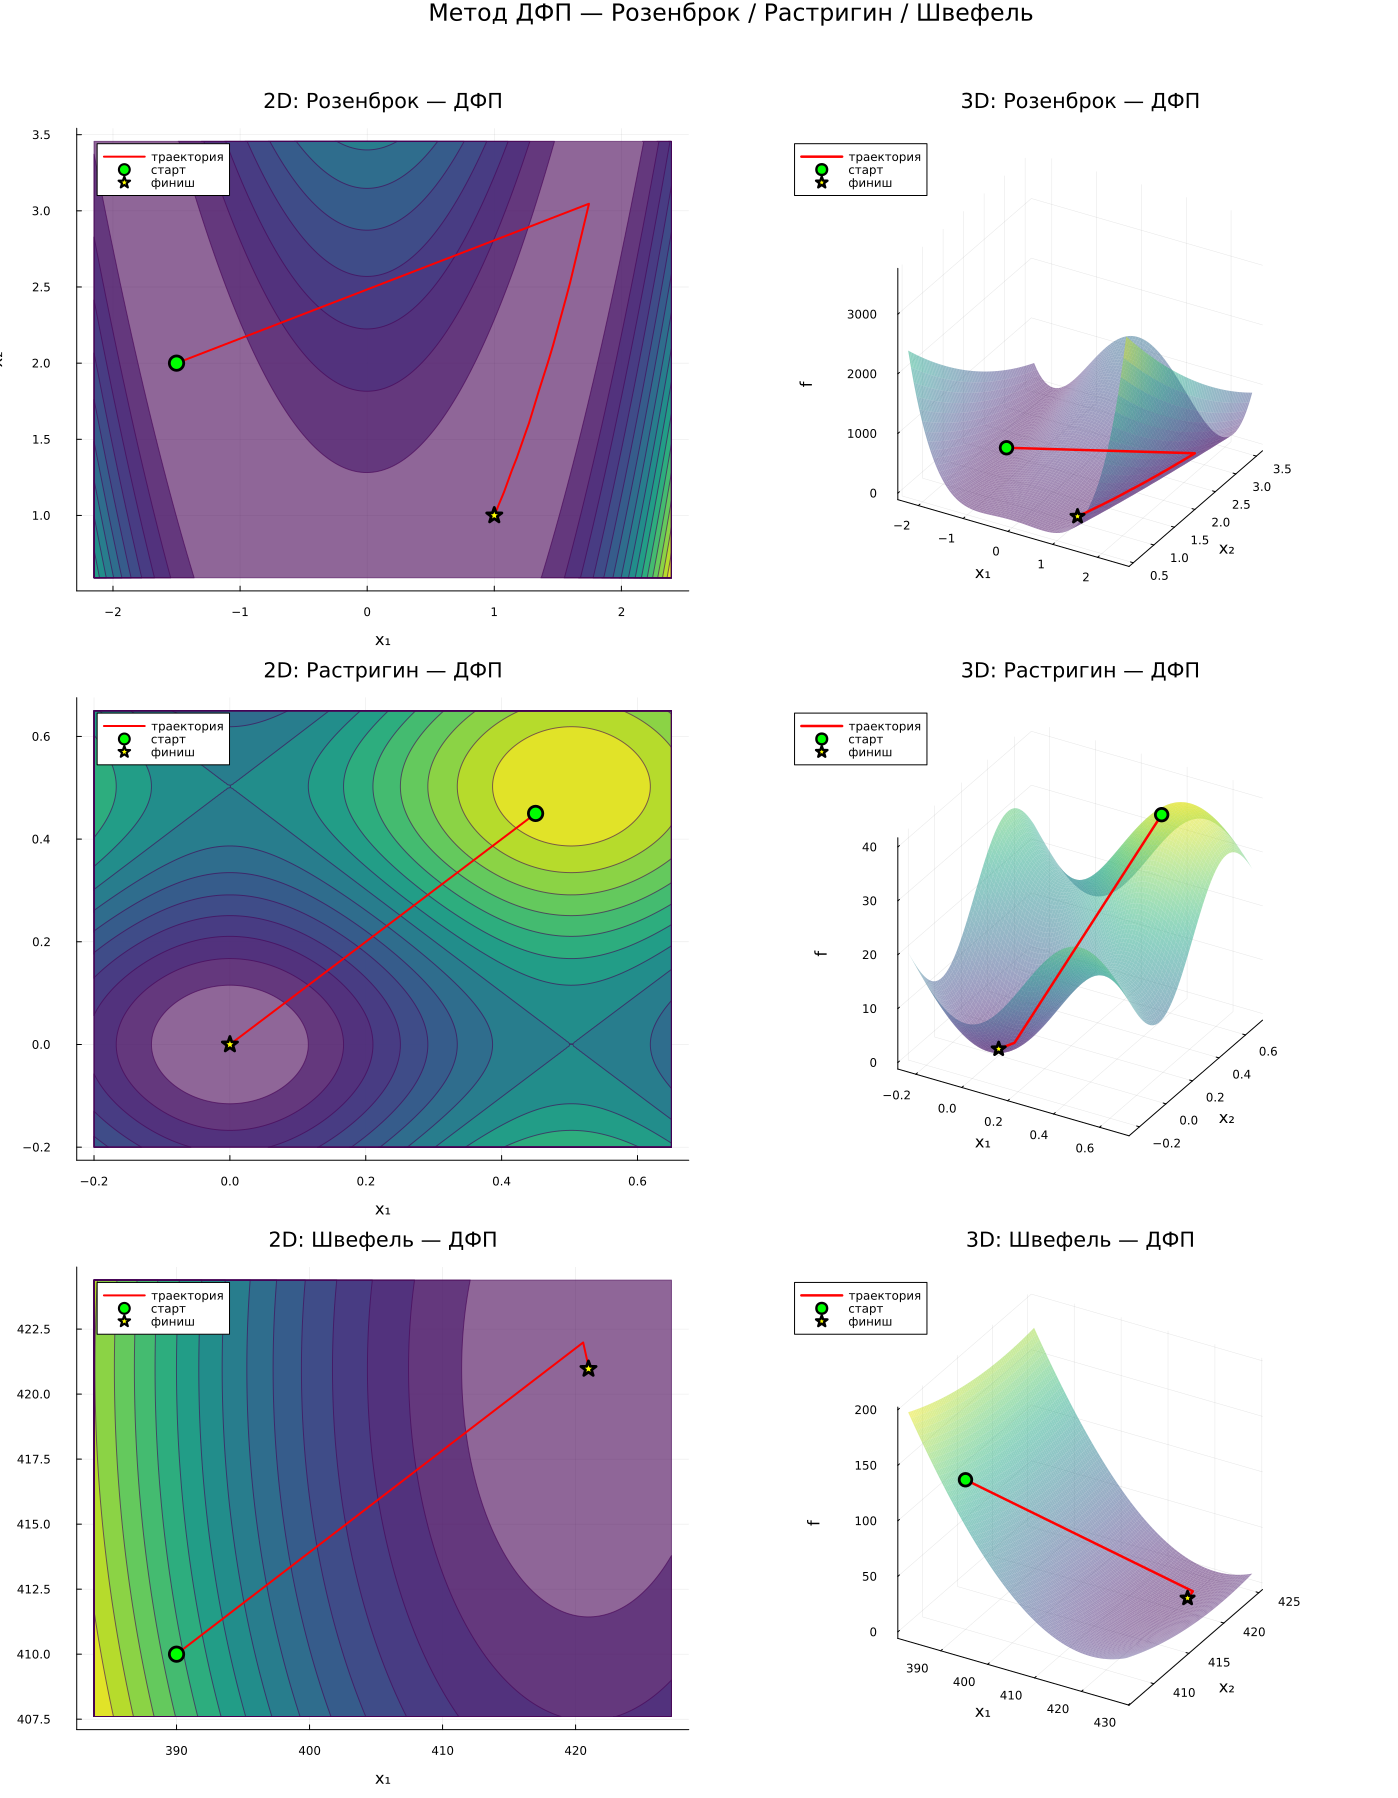

In [15]:
using LinearAlgebra
using Plots
gr()


f_rosen(x)  = (1.0 - x[1])^2 + 100.0 * (x[2] - x[1]^2)^2
f_rast(x)   = 20.0 + x[1]^2 - 10.0*cos(2π*x[1]) + x[2]^2 - 10.0*cos(2π*x[2])
f_schwef(x) = 418.9829*2 - (x[1]*sin(sqrt(abs(x[1]))) + x[2]*sin(sqrt(abs(x[2]))))


function numgrad(f, x; h=1e-6)
    n  = length(x)
    xv = collect(Float64, x)
    g  = zeros(Float64, n)
    for i in 1:n
        ei   = zeros(Float64, n); ei[i] = 1.0
        g[i] = (f(xv .+ h .* ei) - f(xv .- h .* ei)) / (2h)
    end
    return g
end

function golden_section(φ, a=0.0, b=1.0; tol=1e-6, max_iter=200)
    gr = (sqrt(5.0) + 1.0) / 2.0
    c  = b - (b - a) / gr
    d  = a + (b - a) / gr
    for _ in 1:max_iter
        abs(b - a) < tol && break
        if φ(c) < φ(d)
            b = d
        else
            a = c
        end
        c = b - (b - a) / gr
        d = a + (b - a) / gr
    end
    return (a + b) / 2.0
end

function dfp(f, x0; epsilon1=1e-6, epsilon2=1e-6, max_iters=500, alpha_max=1.0)
    x    = collect(Float64, x0)
    n    = length(x)
    H    = Matrix{Float64}(I, n, n)
    grad = numgrad(f, x)
    hist = [copy(x)]

    for _ in 1:max_iters
        norm(grad) < epsilon2 && break

        p    = H * grad
        φ(α) = f(x .- α .* p)
        α    = golden_section(φ, 0.0, alpha_max)

        x_new    = x .- α .* p
        grad_new = numgrad(f, x_new)

        Δx = x_new .- x
        Δg = grad_new .- grad

        norm(Δx) < epsilon1 && break

        dxdg = dot(Δx, Δg)
        if abs(dxdg) > 1e-10 && dxdg > 0
            A   = (Δx * Δx') / dxdg
            z   = H * Δg
            zdg = dot(Δg, z)
            H   = abs(zdg) > 1e-10 ? H + A - (z * z') / zdg : H + A
        end

        if minimum(eigvals(Symmetric(H))) <= 0
            H = Matrix{Float64}(I, n, n)
        end

        x    = x_new
        grad = grad_new
        push!(hist, copy(x))
    end

    return x, hist
end


function print_results(fname, x0, xmin, hist, f)
    println()
    println("═"^60)
    println("  ФУНКЦИЯ : $fname")
    println("  Метод   : ДФП (Дэвидон-Флэтчер-Пауэл)")
    println("═"^60)
    println("  Стартовая точка       : $(round.(x0,     digits=6))")
    println("  Найденный минимум     : $(round.(xmin,   digits=6))")
    println("  Значение f в минимуме : $(round(f(xmin), digits=10))")
    println("  Количество итераций   : $(length(hist) - 1)")
    println("  Точек в релакс. посл. : $(length(hist))")
    println("═"^60)
end


function get_xy(hist)
    [p[1] for p in hist], [p[2] for p in hist]
end

function hist_bounds(hist; pad=0.2)
    xs, ys = get_xy(hist)
    xmin, xmax = minimum(xs), maximum(xs)
    ymin, ymax = minimum(ys), maximum(ys)
    dx = max(xmax - xmin, 1.0)
    dy = max(ymax - ymin, 1.0)
    return xmin - pad*dx, xmax + pad*dx, ymin - pad*dy, ymax + pad*dy
end

function plot2d(f, hist, fname; gridN=200)
    xmin, xmax, ymin, ymax = hist_bounds(hist)
    xg = range(xmin, xmax; length=gridN)
    yg = range(ymin, ymax; length=gridN)
    Z  = [f([x, y]) for y in yg, x in xg]
    xs, ys = get_xy(hist)

    p = contourf(xg, yg, Z;
                 color=:viridis, alpha=0.6, colorbar=false,
                 xlabel="x₁", ylabel="x₂",
                 title="2D: $fname — ДФП")
    plot!(p,    xs,        ys;        lw=2, color=:red,    label="траектория")
    scatter!(p, [xs[1]],   [ys[1]];   ms=8, color=:lime,   label="старт",  markershape=:circle)
    scatter!(p, [xs[end]], [ys[end]]; ms=8, color=:yellow, label="финиш", markershape=:star5)
    return p
end

function plot3d(f, hist, fname; gridN=80)
    xmin, xmax, ymin, ymax = hist_bounds(hist; pad=0.25)
    xg = range(xmin, xmax; length=gridN)
    yg = range(ymin, ymax; length=gridN)
    Z  = [f([x, y]) for y in yg, x in xg]
    xs, ys = get_xy(hist)
    fv     = [f([x, y]) for (x, y) in zip(xs, ys)]

    p = surface(xg, yg, Z;
                alpha=0.5, color=:viridis, colorbar=false,
                xlabel="x₁", ylabel="x₂", zlabel="f",
                title="3D: $fname — ДФП")
    plot!(p,    xs,        ys,        fv;        lw=2.5, color=:red,    label="траектория")
    scatter!(p, [xs[1]],   [ys[1]],   [fv[1]];   ms=7,  color=:lime,   label="старт",  markershape=:circle)
    scatter!(p, [xs[end]], [ys[end]], [fv[end]]; ms=7,  color=:yellow, label="финиш", markershape=:star5)
    return p
end


tests = [
    (f_rosen,  "Розенброк", [-1.5,   2.0  ], 1.0),
    (f_rast,   "Растригин", [ 0.45,  0.45 ], 0.02),
    (f_schwef, "Швефель",   [390.0, 410.0 ], 5.0),
]

all_plots = Plots.Plot[]

for (f, fname, x0, amax) in tests
    xmin, hist = dfp(f, x0; alpha_max=amax)
    print_results(fname, x0, xmin, hist, f)
    push!(all_plots, plot2d(f, hist, fname))
    push!(all_plots, plot3d(f, hist, fname))
end

display(plot(all_plots...;
             layout     = (3, 2),
             size       = (1400, 1800),
             plot_title = "Метод ДФП — Розенброк / Растригин / Швефель"))